In [6]:
import numpy as np
import pandas as pd


In [7]:
df=pd.read_csv('insurance.csv')

##### Understanding about Data

In [61]:
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [16]:
df.isnull().sum()


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

#### Preprocessing

In [24]:
categorical = ['sex', 'smoker', 'region']
numerical = ['age', 'bmi', 'children']

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [25]:
from sklearn.compose import ColumnTransformer

In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical = ['sex', 'smoker', 'region']
numerical = ['age', 'bmi', 'children']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical),
        ('num', StandardScaler(), numerical)
    ]
)


In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

#### pipeline

In [41]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

##### splitting data

In [42]:
X = df.drop('charges', axis=1)
y = df['charges']

In [43]:
from sklearn.model_selection import train_test_split

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [45]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['sex', 'smoker', 'region']),
                                                 ('num', StandardScaler(),
                                                  ['age', 'bmi',
                                                   'children'])])),
                ('regressor', LinearRegression())])

##### Doing Prediction

In [46]:
y_pred = model.predict(X_test)

In [47]:
print(y_pred)

[ 8969.55027444  7068.74744287 36858.41091155  9454.67850053
 26973.17345656 10864.11316424   170.28084137 16903.45028662
  1092.43093614 11218.34318352 28101.68455267  9377.73460205
  5263.0595179  38416.04221107 40255.82339284 37098.25353123
 15240.39392306 35912.88264434  9112.52398703 31461.92108909
  3847.68845883 10130.12001517  2370.54189389  7140.21550828
 11301.76782638 12961.65366224 14509.47251876  6159.8976107
  9963.85857263  2177.85718217  9115.93673494 13073.68932159
  4561.82376202  3408.20756033  4459.81359745 13032.06505076
  1979.99357292  8813.28303303 33271.29124448 32585.51583927
  3908.76090964  4326.10774721 14142.81326533 11423.45494846
  8774.13955311 12097.28051001  5281.57353499  3150.5596042
 35494.46461214  9150.1124786  15836.84575621  2343.57470069
 12364.78414194  1482.29488266 13389.06105161 12573.57395972
  4341.83680558 32165.33688042 13321.3360032  12896.82071102
 14167.99421483 10506.17623512 16360.78543548  7763.89824584
 11839.25019431  4061.1975

In [48]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.7835929767120731
RMSE: 5796.284659276263


The linear regression model achieved an R² of 0.78, explaining about 78% of variance in medical charges. The RMSE was around 5800, indicating moderate prediction error. Smoking status was a major contributor to charges.

#### Visualization

In [ ]:
##Charges Distribution

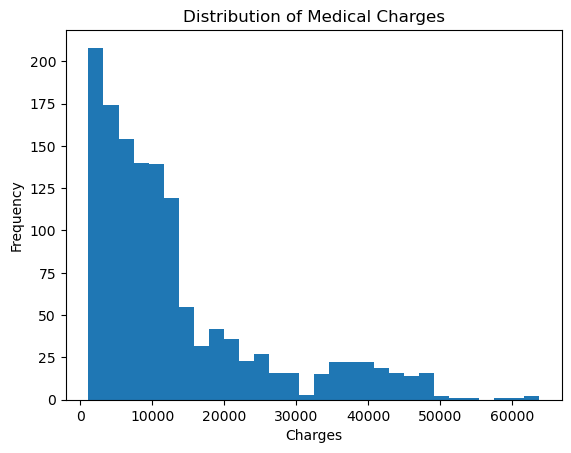

In [49]:
import matplotlib.pyplot as plt
plt.figure()
plt.hist(df['charges'], bins=30)
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.title("Distribution of Medical Charges")
plt.show()

In [50]:
##Charges vs Age

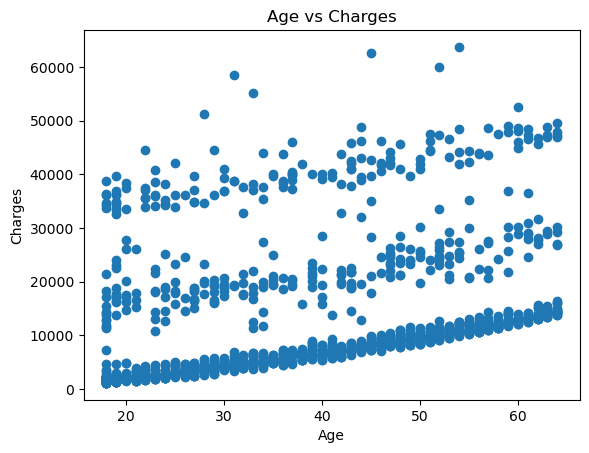

In [51]:
plt.figure()
plt.scatter(df['age'], df['charges'])
plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Age vs Charges")
plt.show()

In [ ]:
###Smoker vs Charges

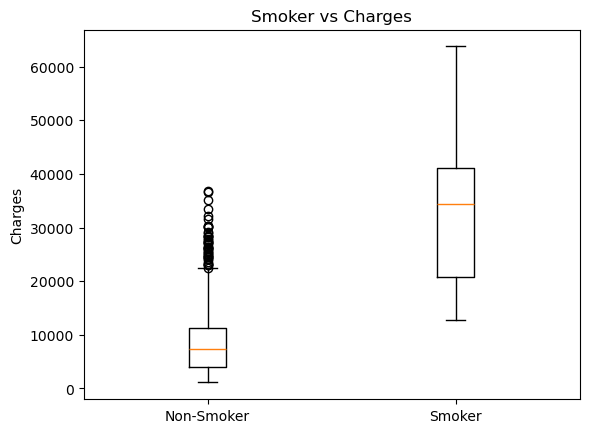

In [52]:
plt.figure()
plt.boxplot(
    [df[df['smoker']=='no']['charges'],
     df[df['smoker']=='yes']['charges']]
)
plt.xticks([1,2], ['Non-Smoker','Smoker'])
plt.ylabel("Charges")
plt.title("Smoker vs Charges")
plt.show()

In [ ]:
##Correlation Heatmap

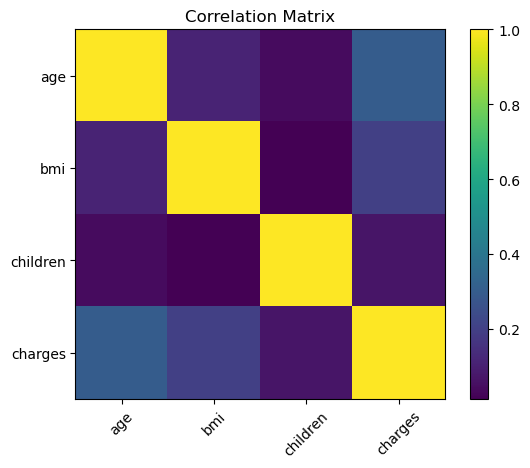

In [53]:
import numpy as np

corr = df.corr(numeric_only=True)

plt.figure()
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

In [ ]:
###Model Evaluation Plot

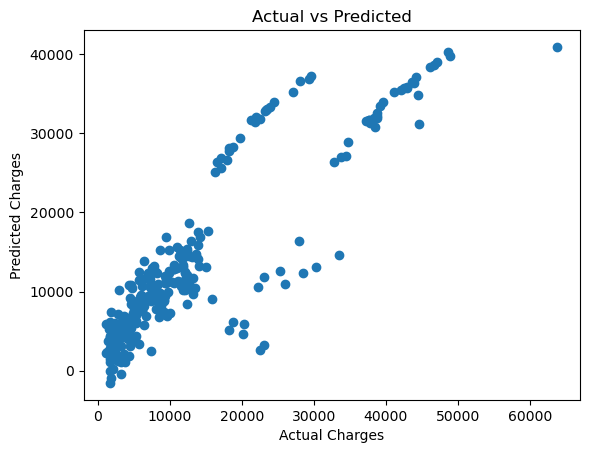

In [54]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted")
plt.show()

In [55]:
##Residual Normality

In [56]:
residuals = y_test - y_pred

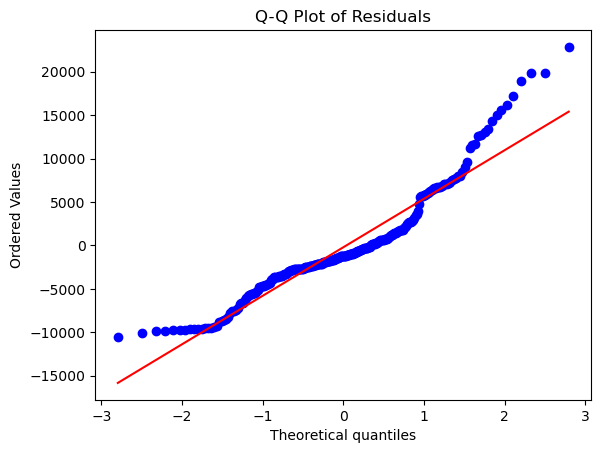

In [57]:
import matplotlib.pyplot as plt
import scipy.stats as stats

plt.figure()
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

Residuals are approximately normal
Linear regression assumption satisfied